# 6CS012 – Final Integrated Assessment
## Part II: Vision Tasks – Fruit Image Classification
**Dataset:** Fruit Classification (Banana, Cherry, Grape, Mango, Peach)

> Run on Google Colab: Runtime → Change runtime type → **GPU**

**Note:** Test folder contains unlabelled flat images. All evaluation is done on the 20% validation split carved from Train (labels known).

## 1. Dataset Setup – Load from Google Drive

In [6]:
import os, zipfile
from google.colab import drive
from PIL import Image

drive.mount('/content/drive', force_remount=False)

DRIVE_ZIP  = '/content/drive/MyDrive/AI/FruitClassification.zip'
EXTRACT_TO = '/content/FruitClassification'

if not os.path.exists(DRIVE_ZIP):
    raise FileNotFoundError(f'ZIP not found at {DRIVE_ZIP}')

if os.path.exists(EXTRACT_TO) and len(os.listdir(EXTRACT_TO)) > 0:
    print('Already extracted – skipping.')
else:
    print('Extracting...')
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as zf:
        zf.extractall(EXTRACT_TO)
    print('Done.')

print(os.listdir(EXTRACT_TO))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already extracted – skipping.
['Fruit Classification']


## 2. Import Libraries

In [7]:
import os, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Configure Paths

In [8]:
BASE = '/content/FruitClassification'

def find_split(base, candidates):
    for dirpath, dirs, _ in os.walk(base):
        available = {d.lower(): d for d in dirs}
        for c in candidates:
            if c in available:
                return os.path.join(dirpath, available[c])
    return None

TRAIN_DIR = find_split(BASE, ['train', 'training'])
TEST_DIR  = find_split(BASE, ['test',  'testing'])

print(f'Train : {TRAIN_DIR}')
print(f'Test  : {TEST_DIR}')

IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
NUM_CLASSES = len([d for d in os.listdir(TRAIN_DIR)
                   if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f'Classes: {NUM_CLASSES}')


Train : /content/FruitClassification/Fruit Classification/Train
Test  : /content/FruitClassification/Fruit Classification/Test
Classes: 5


## 4. Data Cleaning – Remove Corrupt / Non-Image Files

In [9]:
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}

def clean_dir(root, label=''):
    removed, kept = 0, 0
    for dirpath, _, fnames in os.walk(root):
        for fname in fnames:
            fpath = os.path.join(dirpath, fname)
            ext   = os.path.splitext(fname)[1].lower()
            if ext not in VALID_EXT:
                os.remove(fpath)
                removed += 1
                continue
            try:
                with Image.open(fpath) as img:
                    img.verify()
                kept += 1
            except Exception:
                os.remove(fpath)
                removed += 1
    print(f'{label}: kept {kept}, removed {removed}')

clean_dir(TRAIN_DIR, 'Train')
clean_dir(TEST_DIR,  'Test')
print('Dataset cleaned.')


Train: kept 6242, removed 0
Test: kept 5, removed 0
Dataset cleaned.


## 5. Data Understanding, Analysis & Visualization
*(Assessment Section 2.5.1)*

In [10]:
# Q1: Dataset description
print("""Q1: Dataset Description
Multi-class image classification dataset with 5 fruit categories:
Banana, Cherry, Grape, Mango, Peach.
Train folder: class sub-folders with labelled images.
Test folder:  flat folder of unlabelled images (no ground truth).
All evaluation is performed on the validation split from Train.
""")

# Q2 & Q3: Image counts
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        p = os.path.join(directory, cls)
        if not os.path.isdir(p): continue
        counts[cls] = len([f for f in os.listdir(p)
                           if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return counts

train_counts = count_images(TRAIN_DIR)

# Test folder is flat — just count all image files directly
test_total = len([f for f in os.listdir(TEST_DIR)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))])

df = pd.DataFrame({'Train Images': train_counts})
df = df.sort_values('Train Images', ascending=False)

print(f"Q2: Total train images : {df['Train Images'].sum()}")
print(f"    Total test images  : {test_total}  (unlabelled, flat folder)")
print(f"\nQ3: Class Distribution in Train Set:")
print(df)


Q1: Dataset Description
Multi-class image classification dataset with 5 fruit categories:
Banana, Cherry, Grape, Mango, Peach.
Train folder: class sub-folders with labelled images.
Test folder:  flat folder of unlabelled images (no ground truth).
All evaluation is performed on the validation split from Train.

Q2: Total train images : 6242
    Total test images  : 5  (unlabelled, flat folder)

Q3: Class Distribution in Train Set:
        Train Images
Grape           1468
Banana          1422
Cherry          1222
Peach           1222
Mango            908


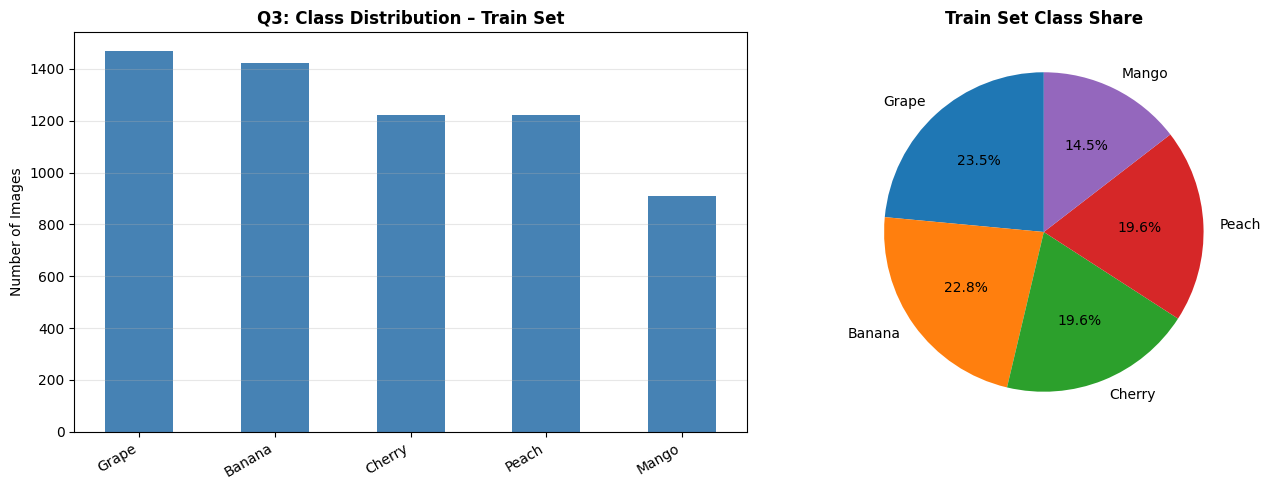

In [11]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(df))
axes[0].bar(x, df['Train Images'], color='steelblue', width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df.index, rotation=30, ha='right')
axes[0].set_title('Q3: Class Distribution – Train Set', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(df['Train Images'], labels=df.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Train Set Class Share', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Q4: Train/Validation Split
No separate validation folder exists. ImageDataGenerator validation_split=0.2
holds out 20% of Train images as validation (stratified, seed=42).
This gives ~80% train / ~20% validation with no data leakage.

Q5: Preprocessing
- Resize all images to 128x128 (uniform CNN input)
- Rescale pixel values [0,255] → [0.0,1.0]
- Corrupt / non-image files removed (Section 4)



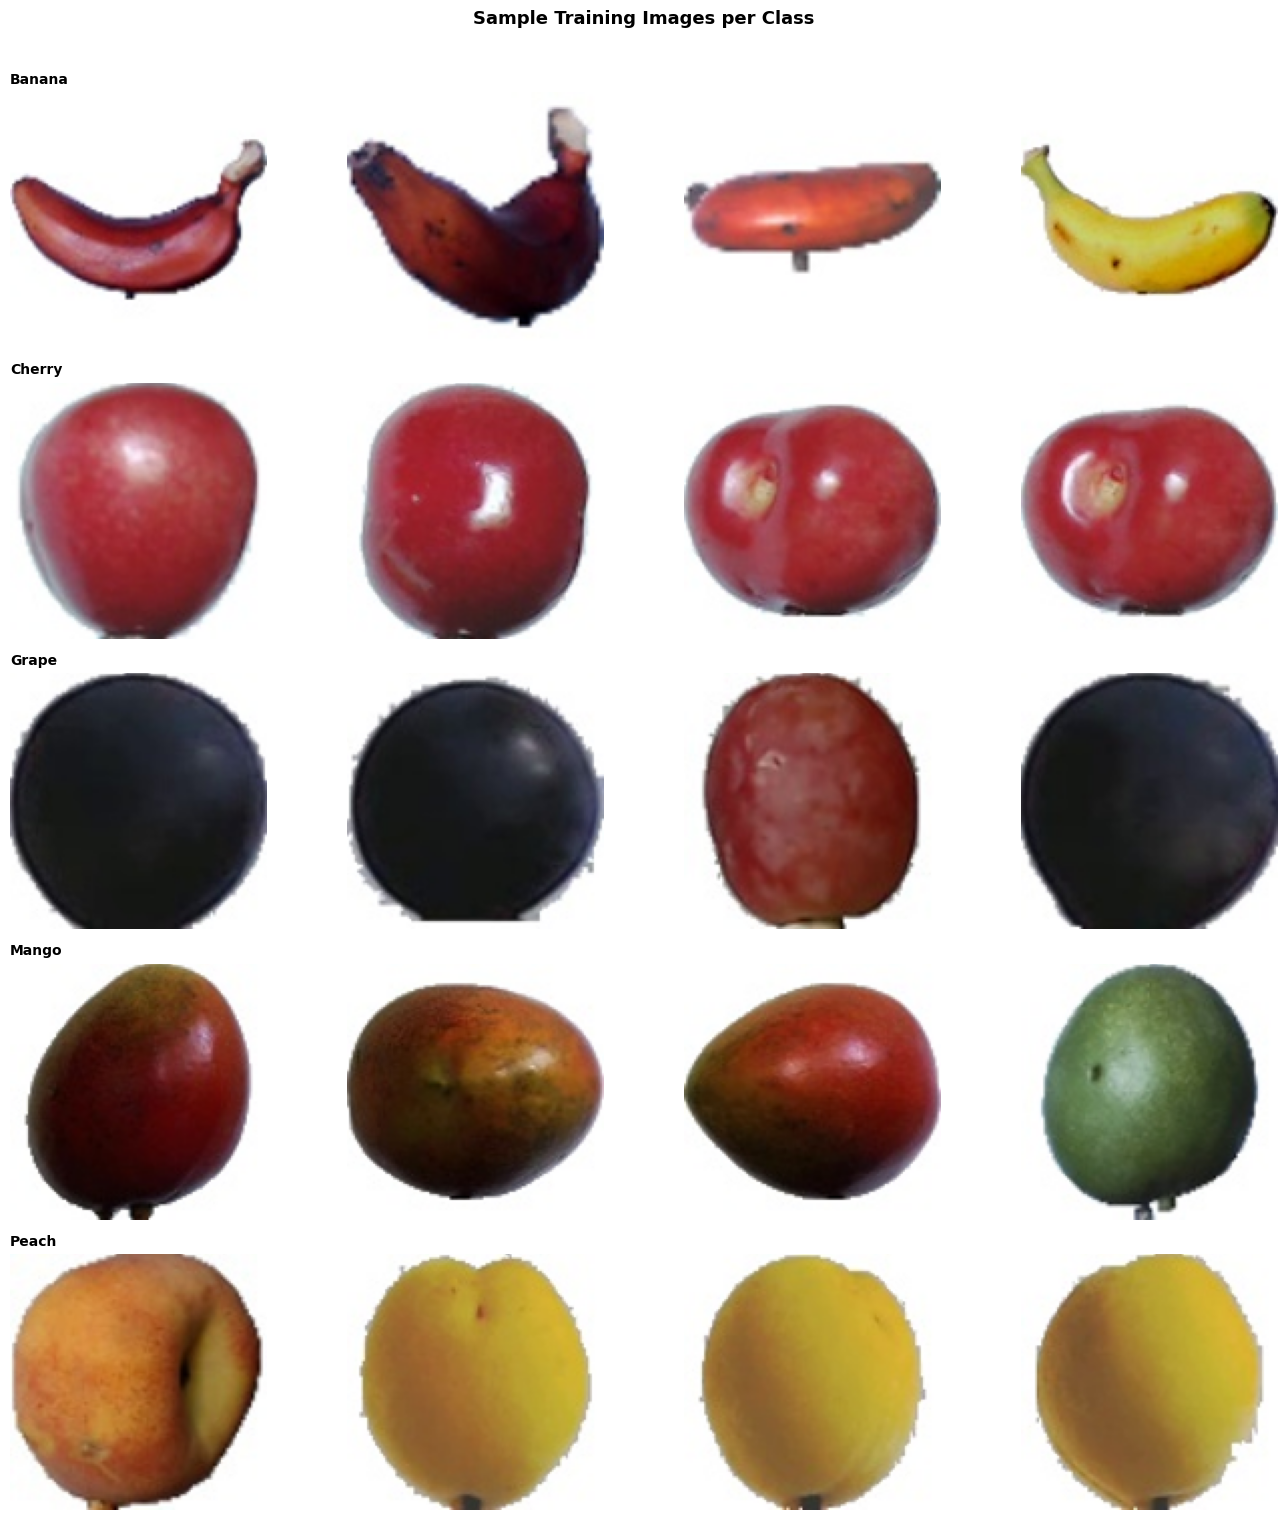

In [12]:
# Q4: Split justification
print("""Q4: Train/Validation Split
No separate validation folder exists. ImageDataGenerator validation_split=0.2
holds out 20% of Train images as validation (stratified, seed=42).
This gives ~80% train / ~20% validation with no data leakage.
""")

# Q5: Preprocessing
print("""Q5: Preprocessing
- Resize all images to 128x128 (uniform CNN input)
- Rescale pixel values [0,255] → [0.0,1.0]
- Corrupt / non-image files removed (Section 4)
""")

# Q6: Sample images
CLASSES = sorted([d for d in os.listdir(TRAIN_DIR)
                  if os.path.isdir(os.path.join(TRAIN_DIR, d))])
n_cols  = 4
fig, axes = plt.subplots(len(CLASSES), n_cols, figsize=(14, 3*len(CLASSES)))
for i, cls in enumerate(CLASSES):
    p    = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for j, fname in enumerate(random.sample(imgs, min(n_cols, len(imgs)))):
        ax = axes[i][j]
        ax.imshow(Image.open(os.path.join(p, fname)).resize((128,128)))
        ax.axis('off')
        if j == 0:
            ax.set_title(cls, fontweight='bold', loc='left', fontsize=10)
plt.suptitle('Sample Training Images per Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Data Generators

In [13]:
img_width, img_height = 128, 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(img_width, img_height), batch_size=batch_size,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)
validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(img_width, img_height), batch_size=batch_size,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

classes      = list(train_generator.class_indices.keys())
class_labels = classes
NUM_CLASSES  = train_generator.num_classes
print(f'Classes      : {classes}')
print(f'Train images : {train_generator.n}')
print(f'Val images   : {validation_generator.n}')


Found 4996 images belonging to 5 classes.
Found 1246 images belonging to 5 classes.
Classes      : ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']
Train images : 4996
Val images   : 1246


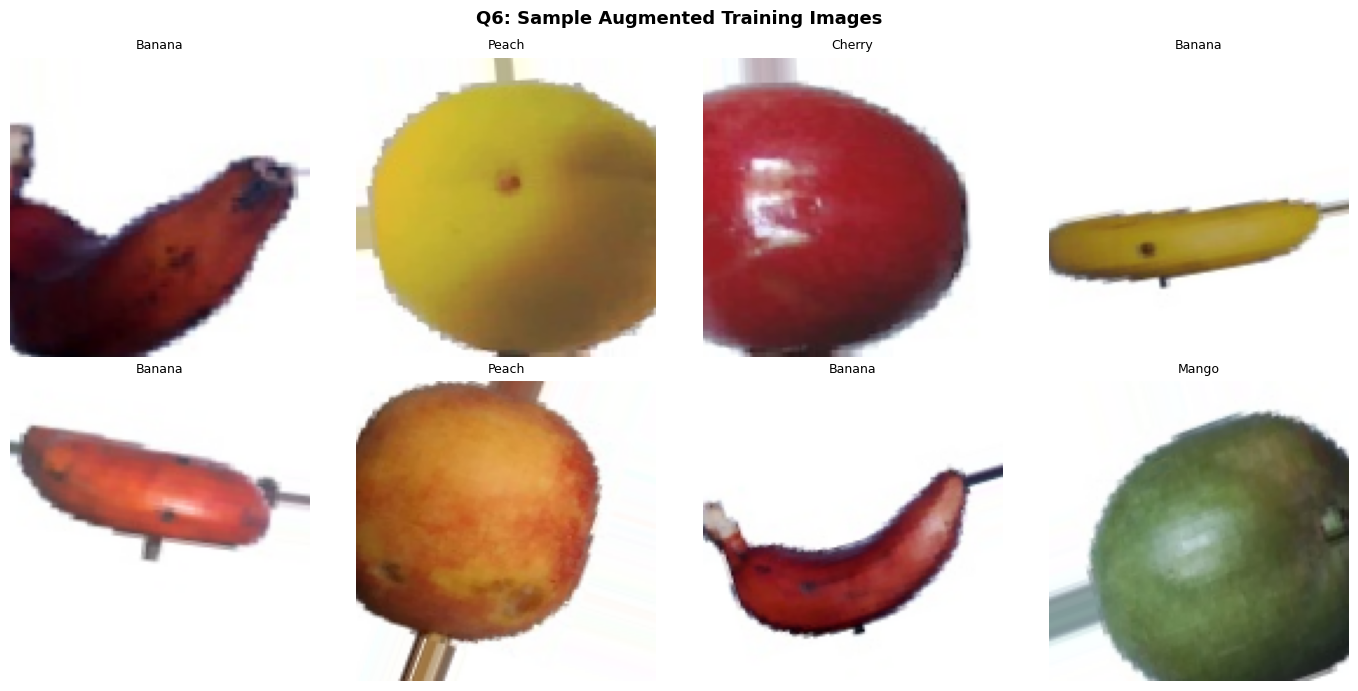

In [14]:
# Q6 (cont): Visualise augmented images
sample_imgs, sample_labels = next(train_generator)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i in range(8):
    axes[i].imshow(sample_imgs[i])
    axes[i].set_title(classes[np.argmax(sample_labels[i])], fontsize=9)
    axes[i].axis('off')
plt.suptitle('Q6: Sample Augmented Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Part A: CNN from Scratch
## 7. Helper Functions

In [15]:
def plot_history(history, title='Model', save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train',      color='steelblue',  lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='darkorange', lw=2, ls='--')
    axes[0].set_title(f'{title} - Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train',      color='steelblue',  lw=2)
    axes[1].plot(history.history['val_loss'], label='Validation', color='darkorange', lw=2, ls='--')
    axes[1].set_title(f'{title} - Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_name: plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def full_evaluate(model, generator, model_name='Model', cmap='Blues'):
    """Classification report + confusion matrix on validation set."""
    generator.reset()
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes
    names  = list(generator.class_indices.keys())
    print(f'\n{"="*55}')
    print(f'  {model_name} - Evaluation Report')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(7, len(names)), max(5, len(names)-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=names, yticklabels=names, linewidths=.5)
    plt.title(f'{model_name} - Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return y_pred, y_true


def predict_on_val_samples(model, generator, classes, n=8,
                            model_name='Model', preprocess_fn=None):
    """
    Show n random validation images with true vs predicted label.
    Uses validation_generator (labelled) NOT the flat test folder.
    """
    generator.reset()
    imgs_shown, labels_shown = [], []
    for imgs, labels in generator:
        imgs_shown.append(imgs)
        labels_shown.append(labels)
        if sum(len(l) for l in labels_shown) >= n:
            break
    imgs_all   = np.concatenate(imgs_shown,   axis=0)[:n]
    labels_all = np.concatenate(labels_shown, axis=0)[:n]

    preds = model.predict(imgs_all, verbose=0)

    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = np.array(axes).flatten()
    for i in range(n):
        true_cls = classes[np.argmax(labels_all[i])]
        pred_cls = classes[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = 'green' if pred_cls == true_cls else 'red'
        # Reverse normalisation for display
        display_img = np.clip(imgs_all[i], 0, 1)
        axes[i].imshow(display_img)
        axes[i].axis('off')
        axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                          color=color, fontsize=9, fontweight='bold')
    for ax in axes[n:]: ax.axis('off')
    plt.suptitle(f'{model_name} - Sample Validation Predictions',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'preds_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Helper functions ready.')


Helper functions ready.


## 8. Baseline CNN – 3 Conv Blocks + 3 FCN Layers
*(Assessment Section 2.5.2)*

In [16]:
model = Sequential([
    Input(shape=(img_width, img_height, 3)),

    # Conv Block 1 — 32 filters, 3x3, ReLU
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Conv Block 2 — 64 filters, 3x3, ReLU
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Conv Block 3 — 128 filters, 3x3, ReLU
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # 3 Fully Connected Layers
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),

    # Output — 5 fruit classes
    Dense(NUM_CLASSES, activation='softmax')
], name='Baseline_CNN')

model.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,035,845 (64.99 MB)

 Trainable params: 17,035,845 (64.99 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_baseline.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Training Baseline CNN...')
t0 = time.time()
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=baseline_callbacks,
    verbose=1
)
baseline_time = time.time() - t0
print(f'Training time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)')


Training Baseline CNN...
Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6364 - loss: 0.8716
Epoch 1: val_accuracy improved from None to 0.98636, saving model to best_baseline.keras

Epoch 1: finished saving model to best_baseline.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 253ms/step - accuracy: 0.8279 - loss: 0.4428 - val_accuracy: 0.9864 - val_loss: 0.0688 - learning_rate: 0.0010
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9799 - loss: 0.0599
Epoch 2: val_accuracy improved from 0.98636 to 0.99759, saving model to best_baseline.keras

Epoch 2: finished saving model to best_baseline.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 203ms/step - accuracy: 0.9834 - loss: 0.0521 - val_accuracy: 0.9976 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9794 - loss: 0.0637
Epoch 3: val_accuracy did not improve from 0.99759
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.9844 - loss: 0.0541 - v

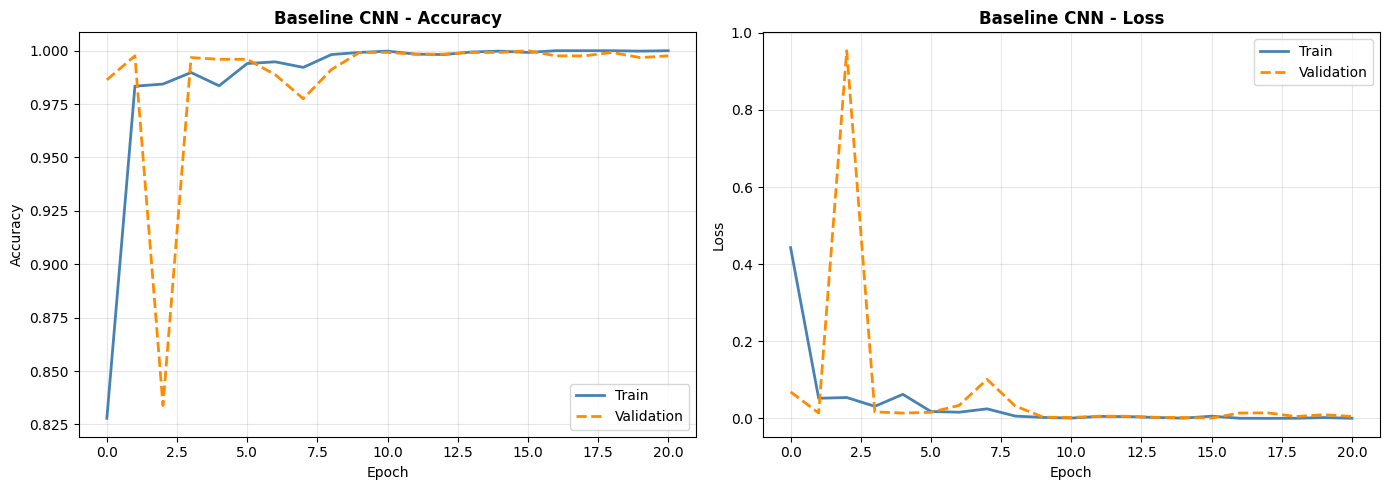

Final Train Acc : 100.00%
Final Val Acc   : 99.76%
Overfitting Gap : 0.24%


In [18]:
plot_history(history, title='Baseline CNN', save_name='history_baseline.png')

t = history.history['accuracy'][-1]
v = history.history['val_accuracy'][-1]
print(f'Final Train Acc : {t*100:.2f}%')
print(f'Final Val Acc   : {v*100:.2f}%')
print(f'Overfitting Gap : {abs(t-v)*100:.2f}%')



  Baseline CNN - Evaluation Report
              precision    recall  f1-score   support

      Banana       1.00      0.99      1.00       284
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       293
       Mango       1.00      1.00      1.00       181
       Peach       0.99      1.00      1.00       244

    accuracy                           1.00      1246
   macro avg       1.00      1.00      1.00      1246
weighted avg       1.00      1.00      1.00      1246



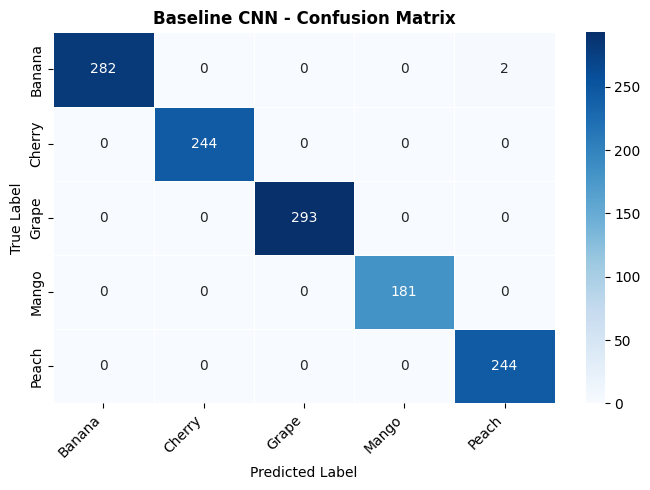

In [19]:
# Full evaluation on validation set (labelled — correct approach)
baseline_preds, baseline_true = full_evaluate(
    model, validation_generator, model_name='Baseline CNN', cmap='Blues')


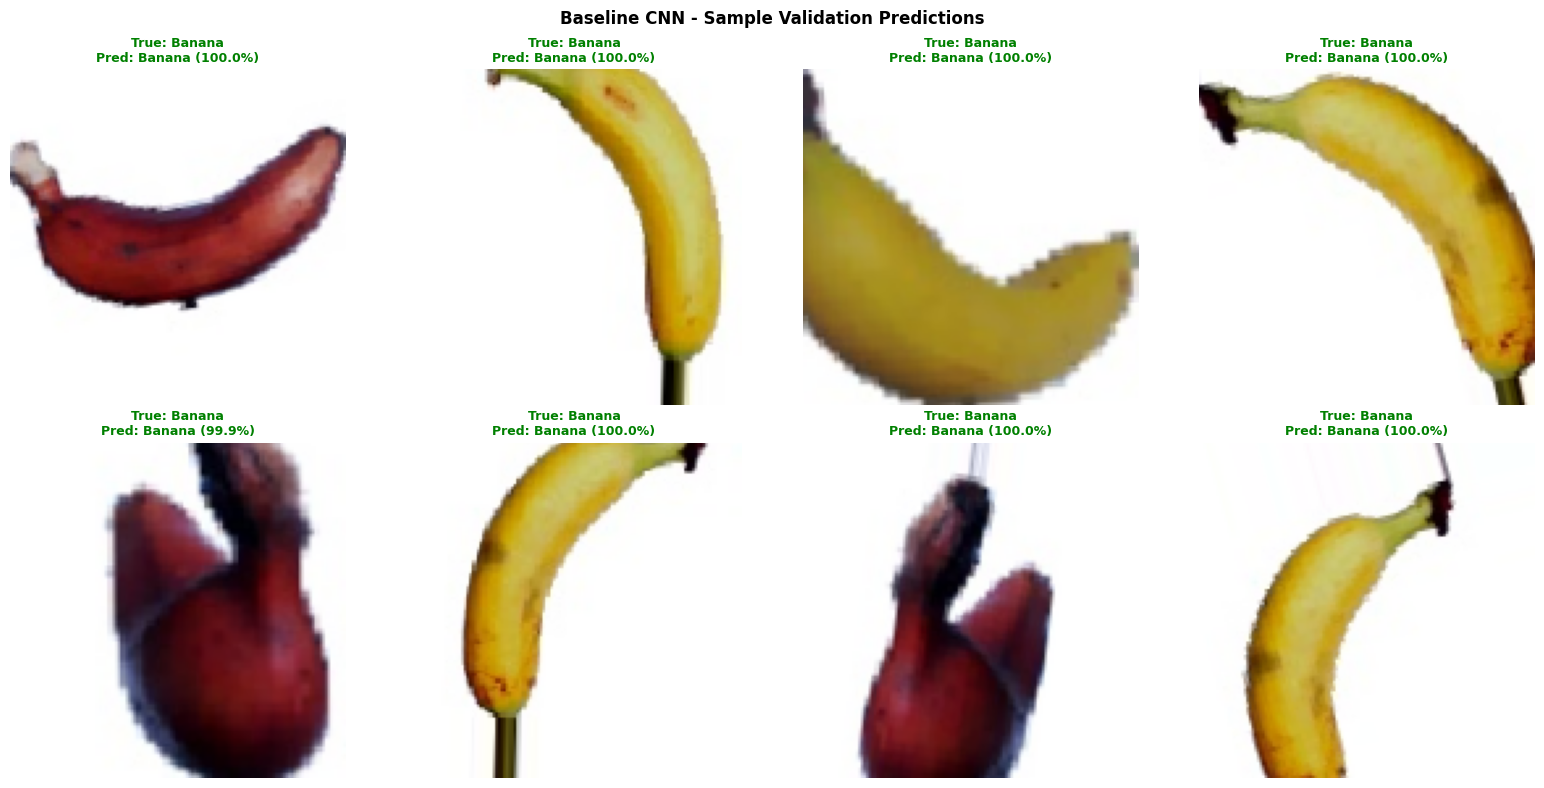

In [20]:
# Sample inference on validation images (labelled — no flat-folder issue)
predict_on_val_samples(model, validation_generator, classes,
                       n=8, model_name='Baseline CNN')


## 9. Deeper CNN – 4 Double-Conv Blocks + BatchNorm + Dropout
*(Assessment Section 2.5.3)*

In [21]:
# 8 conv layers total = more than double the baseline's 3
deeper_model = Sequential([
    Input(shape=(img_width, img_height, 3)),

    # Block 1 — 32 filters
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    # Block 2 — 64 filters
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3 — 128 filters
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 4 — 256 filters
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name='Deeper_CNN')

deeper_model.summary()


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             

 Total params: 9,695,909 (36.99 MB)

 Trainable params: 9,694,949 (36.98 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
deeper_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_deeper.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Training Deeper CNN...')
t0 = time.time()
history_deeper = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=35,
    callbacks=deeper_callbacks,
    verbose=1
)
deeper_time = time.time() - t0
print(f'Training time: {deeper_time:.1f}s ({deeper_time/60:.1f} min)')


Training Deeper CNN...
Epoch 1/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5487 - loss: 4.0528
Epoch 1: val_accuracy improved from None to 0.19583, saving model to best_deeper.keras

Epoch 1: finished saving model to best_deeper.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 338ms/step - accuracy: 0.6922 - loss: 1.7804 - val_accuracy: 0.1958 - val_loss: 2.2779 - learning_rate: 0.0010
Epoch 2/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7884 - loss: 0.6977
Epoch 2: val_accuracy improved from 0.19583 to 0.48395, saving model to best_deeper.keras

Epoch 2: finished saving model to best_deeper.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 215ms/step - accuracy: 0.8062 - loss: 0.7625 - val_accuracy: 0.4839 - val_loss: 1.8465 - learning_rate: 0.0010
Epoch 3/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8271 - loss: 0.6523
Epoch 3: val_accuracy improved from 0.48395 to 0.55618, saving model to best_deeper.keras

Epoch 3: finished saving model to best_deeper.keras

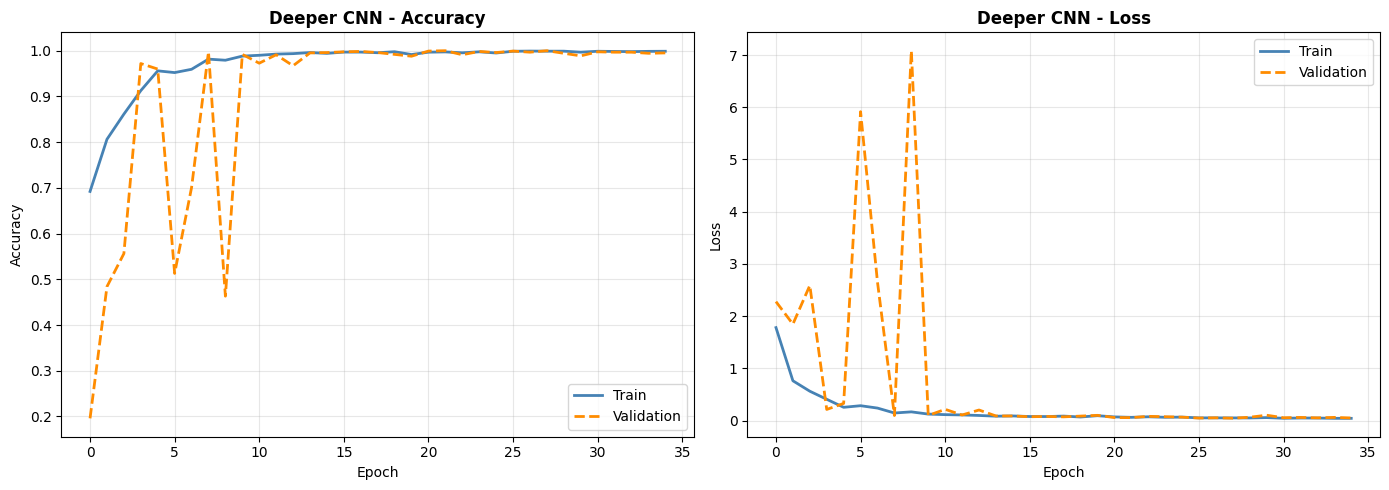


  Deeper CNN - Evaluation Report
              precision    recall  f1-score   support

      Banana       1.00      0.99      1.00       284
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       293
       Mango       1.00      1.00      1.00       181
       Peach       0.99      1.00      1.00       244

    accuracy                           1.00      1246
   macro avg       1.00      1.00      1.00      1246
weighted avg       1.00      1.00      1.00      1246



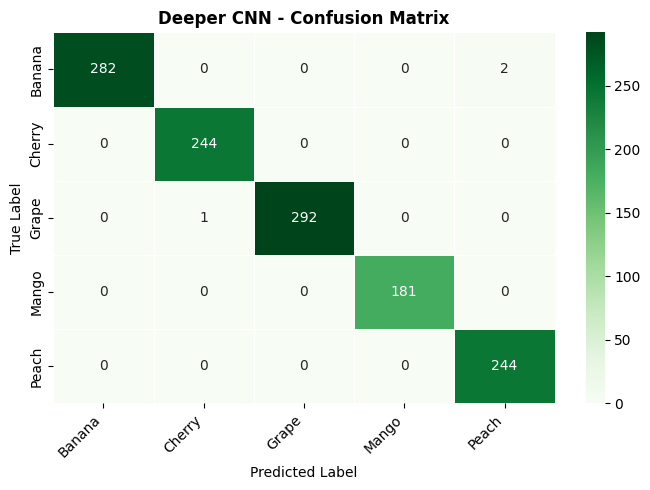

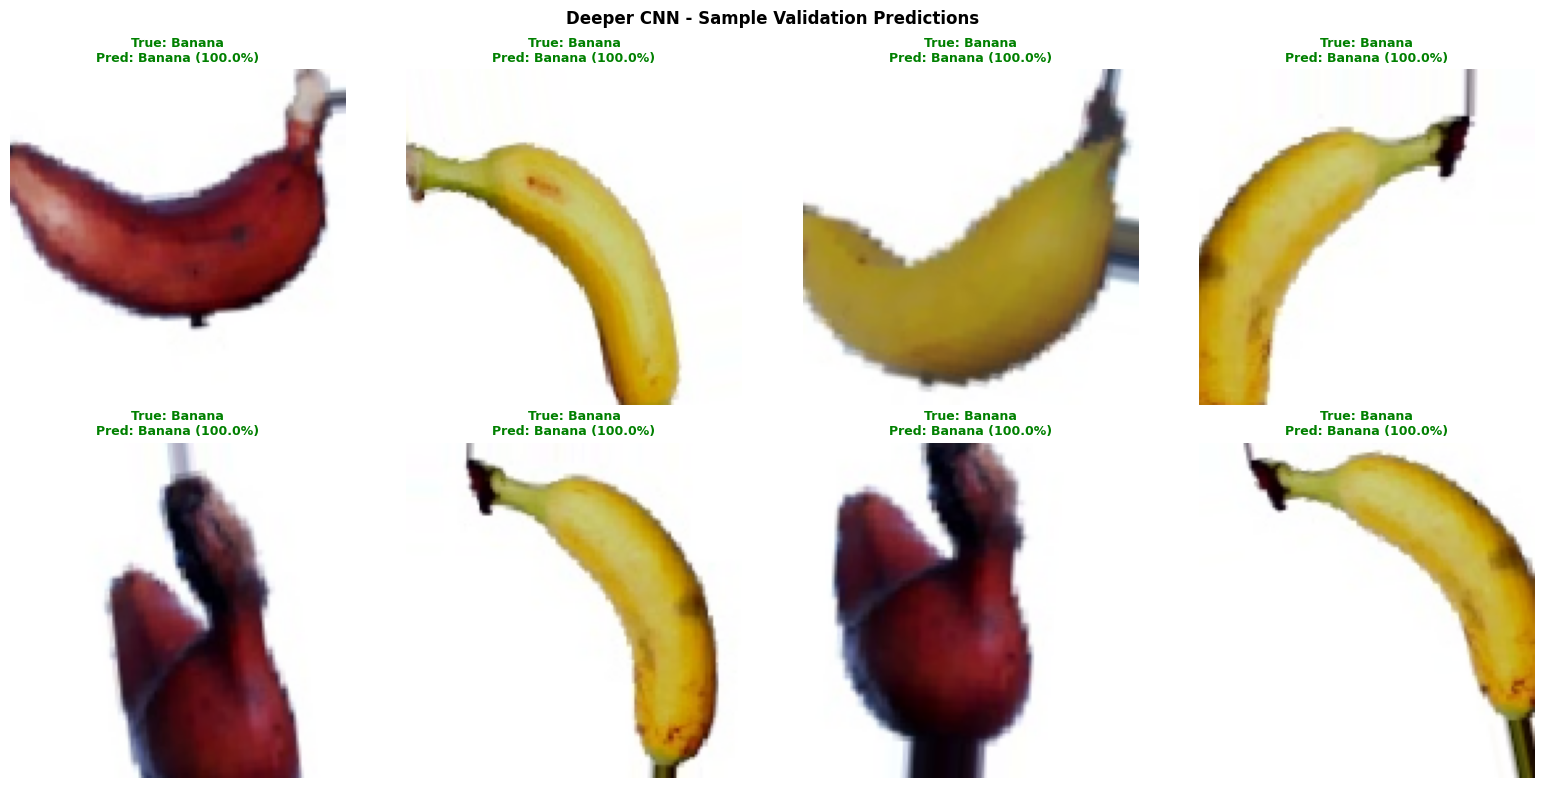

In [23]:
plot_history(history_deeper, title='Deeper CNN', save_name='history_deeper.png')

deeper_preds, deeper_true = full_evaluate(
    deeper_model, validation_generator, model_name='Deeper CNN', cmap='Greens')

predict_on_val_samples(deeper_model, validation_generator, classes,
                       n=8, model_name='Deeper CNN')


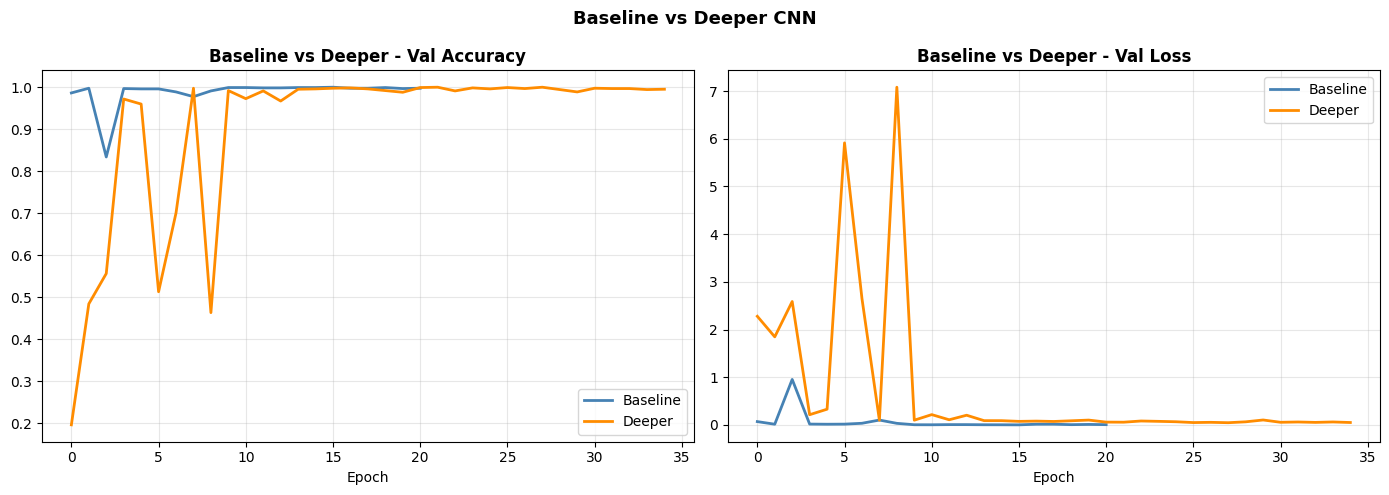

Baseline Best Val Acc : 100.00%
Deeper   Best Val Acc : 100.00%
Baseline Time         : 700.4s
Deeper   Time         : 1231.5s


In [24]:
# Baseline vs Deeper comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, lbl, color in [
    (history,       'Baseline', 'steelblue'),
    (history_deeper,'Deeper',   'darkorange')
]:
    axes[0].plot(hist.history['val_accuracy'], label=lbl, color=color, lw=2)
    axes[1].plot(hist.history['val_loss'],     label=lbl, color=color, lw=2)
for ax, t in zip(axes, ['Val Accuracy', 'Val Loss']):
    ax.set_title(f'Baseline vs Deeper - {t}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Baseline vs Deeper CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline Best Val Acc : {max(history.history["val_accuracy"])*100:.2f}%')
print(f'Deeper   Best Val Acc : {max(history_deeper.history["val_accuracy"])*100:.2f}%')
print(f'Baseline Time         : {baseline_time:.1f}s')
print(f'Deeper   Time         : {deeper_time:.1f}s')


## 10. Optimizer Analysis – SGD vs Adam
*(Assessment Section 2.5.4)*

In [25]:
def build_deeper(num_classes):
    return Sequential([
        Input(shape=(img_width, img_height, 3)),
        Conv2D(32,  (3,3), activation='relu', padding='same'), BatchNormalization(),
        Conv2D(32,  (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)), Dropout(0.2),
        Conv2D(64,  (3,3), activation='relu', padding='same'), BatchNormalization(),
        Conv2D(64,  (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', padding='same'), BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(256, (3,3), activation='relu', padding='same'), BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)), Dropout(0.30),
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(1e-4)), Dropout(0.4),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

opt_cb = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

# SGD
model_sgd = build_deeper(NUM_CLASSES)
model_sgd.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
                  loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
history_sgd = model_sgd.fit(train_generator, validation_data=validation_generator,
                             epochs=40, callbacks=opt_cb, verbose=1)
sgd_time = time.time() - t0
print(f'SGD  time: {sgd_time:.0f}s  Best Val Acc: {max(history_sgd.history["val_accuracy"])*100:.2f}%')

# Adam (fresh weights)
model_adam = build_deeper(NUM_CLASSES)
model_adam.compile(optimizer=Adam(learning_rate=1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
history_adam_opt = model_adam.fit(train_generator, validation_data=validation_generator,
                                   epochs=40, callbacks=opt_cb, verbose=1)
adam_time = time.time() - t0
print(f'Adam time: {adam_time:.0f}s  Best Val Acc: {max(history_adam_opt.history["val_accuracy"])*100:.2f}%')


Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 283ms/step - accuracy: 0.5895 - loss: 1.6364 - val_accuracy: 0.5570 - val_loss: 2.4462 - learning_rate: 0.0100
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 243ms/step - accuracy: 0.7764 - loss: 0.6997 - val_accuracy: 0.3884 - val_loss: 1.9122 - learning_rate: 0.0100
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 206ms/step - accuracy: 0.8068 - loss: 0.6808 - val_accuracy: 0.7400 - val_loss: 1.1704 - learning_rate: 0.0100
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 208ms/step - accuracy: 0.7970 - loss: 0.7400 - val_accuracy: 0.5770 - val_loss: 1.9746 - learning_rate: 0.0100
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 216ms/step - accuracy: 0.8241 - loss: 0.6272 - val_accuracy: 0.9446 - val_loss: 0.3660 - learning_rate: 0.0100
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 208ms/step - accuracy: 0.8289 - loss: 0.6128 - val_accuracy: 0.7255 - val_loss: 1.0182 - learning_rate: 0.0100
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 206ms/step - accuracy: 0.9

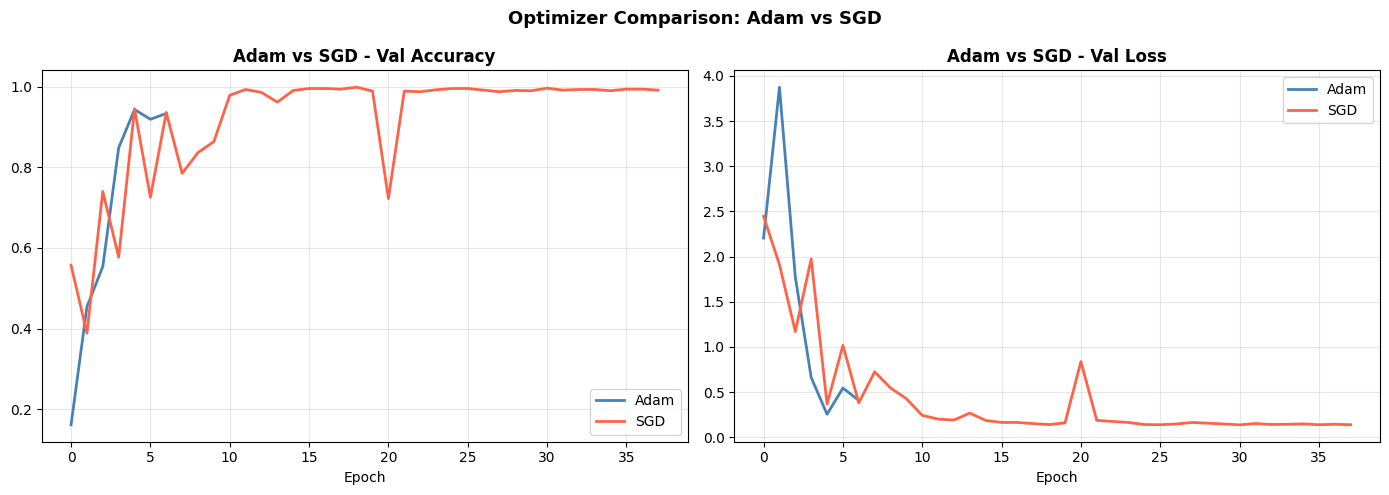


  Deeper CNN SGD - Evaluation Report
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       284
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      0.99      0.99       293
       Mango       0.98      0.99      0.99       181
       Peach       1.00      1.00      1.00       244

    accuracy                           1.00      1246
   macro avg       1.00      1.00      1.00      1246
weighted avg       1.00      1.00      1.00      1246



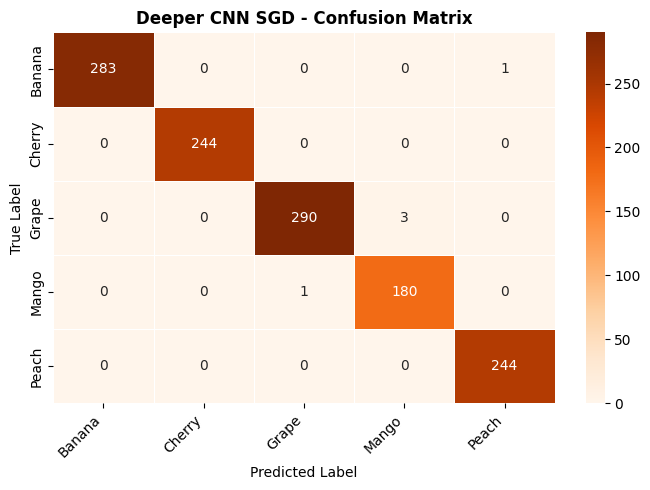


  Deeper CNN Adam - Evaluation Report
              precision    recall  f1-score   support

      Banana       0.00      0.00      0.00       284
      Cherry       0.00      0.00      0.00       244
       Grape       0.12      0.12      0.12       293
       Mango       0.16      0.85      0.27       181
       Peach       0.00      0.00      0.00       244

    accuracy                           0.15      1246
   macro avg       0.06      0.19      0.08      1246
weighted avg       0.05      0.15      0.07      1246



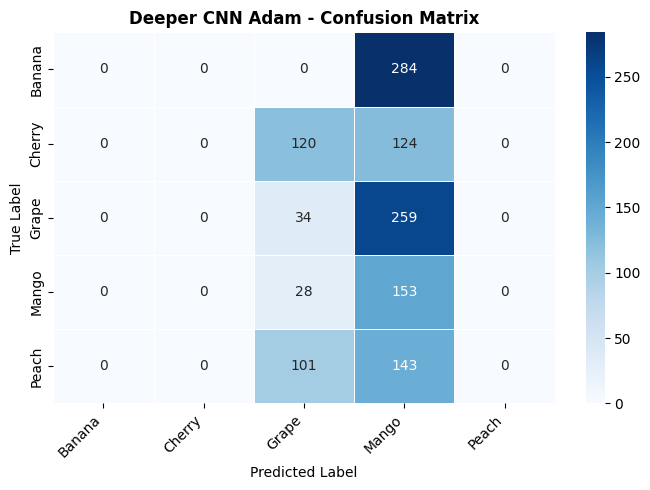

(array([3, 3, 3, ..., 3, 3, 3]), array([0, 0, 0, ..., 4, 4, 4], dtype=int32))

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, lbl, color in [
    (history_adam_opt, 'Adam', 'steelblue'),
    (history_sgd,      'SGD',  'tomato')
]:
    axes[0].plot(hist.history['val_accuracy'], label=lbl, color=color, lw=2)
    axes[1].plot(hist.history['val_loss'],     label=lbl, color=color, lw=2)
for ax, t in zip(axes, ['Val Accuracy', 'Val Loss']):
    ax.set_title(f'Adam vs SGD - {t}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation for both
full_evaluate(model_sgd,  validation_generator, model_name='Deeper CNN SGD',  cmap='Oranges')
full_evaluate(model_adam, validation_generator, model_name='Deeper CNN Adam', cmap='Blues')


## 11. Ablation Study – Removing Dropout
*(Assessment Section 2.5.4)*

In [27]:
ablation_model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(32,  (3,3), activation='relu', padding='same'), BatchNormalization(),
    Conv2D(32,  (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)),
    Conv2D(64,  (3,3), activation='relu', padding='same'), BatchNormalization(),
    Conv2D(64,  (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu', padding='same'), BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)),
    Conv2D(256, (3,3), activation='relu', padding='same'), BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'), MaxPooling2D((2,2)),
    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dense(256, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')   # No Dropout anywhere
], name='Deeper_NoDrop')

ablation_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
ablation_model.summary()

history_ablation = ablation_model.fit(
    train_generator, validation_data=validation_generator,
    epochs=25,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)],
    verbose=1
)


Model: "Deeper_NoDrop"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,695,909 (36.99 MB)

 Trainable params: 9,694,949 (36.98 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 258ms/step - accuracy: 0.8263 - loss: 1.3357 - val_accuracy: 0.3981 - val_loss: 7.4171 - learning_rate: 0.0010
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 210ms/step - accuracy: 0.9680 - loss: 0.2112 - val_accuracy: 0.3892 - val_loss: 10.4398 - learning_rate: 0.0010
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 218ms/step - accuracy: 0.9359 - loss: 0.4151 - val_accuracy: 0.9077 - val_loss: 0.5030 - learning_rate: 0.0010
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 207ms/step - accuracy: 0.9752 - loss: 0.1838 - val_accuracy: 0.9526 - val_loss: 0.3420 - learning_rate: 0.0010
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - accuracy: 0.9846 - loss: 0.1530 - val_accuracy: 0.6605 - val_loss: 5.4169 - learning_rate: 0.0010
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 220ms/step - accuracy: 0.9888 - loss: 0.1175 - val_accuracy: 0.9535 - val_loss: 0.3486 - learning_rate: 0.0010
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 208ms/step - accuracy: 0.

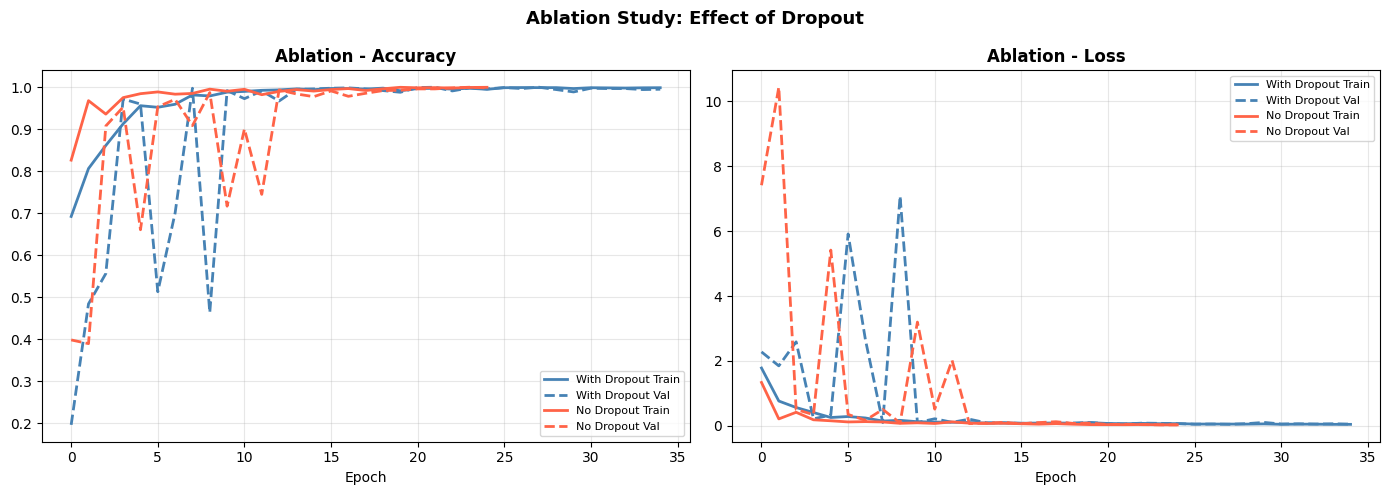

With Dropout - Best Val Acc: 100.00%
No   Dropout - Best Val Acc: 100.00%

  Ablation No Dropout - Evaluation Report
              precision    recall  f1-score   support

      Banana       1.00      0.99      1.00       284
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       293
       Mango       1.00      1.00      1.00       181
       Peach       0.99      1.00      1.00       244

    accuracy                           1.00      1246
   macro avg       1.00      1.00      1.00      1246
weighted avg       1.00      1.00      1.00      1246



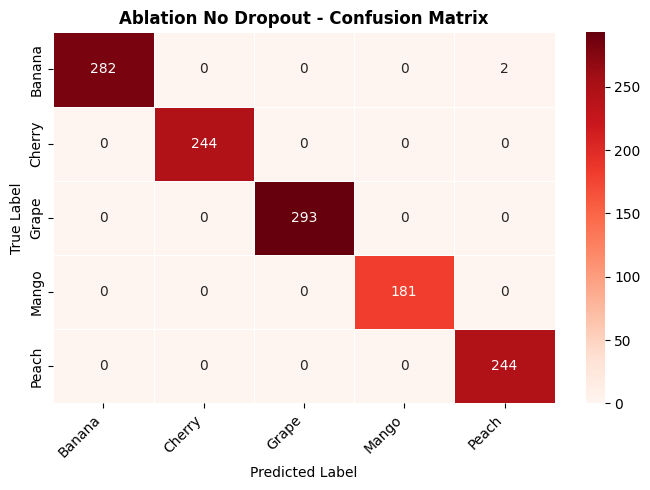

(array([0, 0, 0, ..., 4, 4, 4]), array([0, 0, 0, ..., 4, 4, 4], dtype=int32))

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, lbl, color in [
    (history_deeper,   'With Dropout', 'steelblue'),
    (history_ablation, 'No Dropout',   'tomato')
]:
    axes[0].plot(hist.history['accuracy'],     color=color, lw=2, label=f'{lbl} Train')
    axes[0].plot(hist.history['val_accuracy'], color=color, lw=2, ls='--', label=f'{lbl} Val')
    axes[1].plot(hist.history['loss'],         color=color, lw=2, label=f'{lbl} Train')
    axes[1].plot(hist.history['val_loss'],     color=color, lw=2, ls='--', label=f'{lbl} Val')
for ax, t in zip(axes, ['Accuracy', 'Loss']):
    ax.set_title(f'Ablation - {t}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Ablation Study: Effect of Dropout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

print('With Dropout - Best Val Acc: {:.2f}%'.format(max(history_deeper.history['val_accuracy'])*100))
print('No   Dropout - Best Val Acc: {:.2f}%'.format(max(history_ablation.history['val_accuracy'])*100))

full_evaluate(ablation_model, validation_generator,
              model_name='Ablation No Dropout', cmap='Reds')


---
# Part B: Transfer Learning – VGG16
*(Assessment Section 2.6)*

## 12. Transfer Learning Generators (224×224 + VGG16 Preprocessing)

In [29]:
TL_SIZE  = (224, 224)
TL_BATCH = 32

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
tl_val_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess)

tl_train = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)
tl_valid = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)
print(f'TL Train: {tl_train.n} | TL Valid: {tl_valid.n}')


Found 4996 images belonging to 5 classes.
Found 1246 images belonging to 5 classes.
TL Train: 4996 | TL Valid: 1246


## 13. Phase 1 – Feature Extraction (VGG16 Frozen)

In [30]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x   = GlobalAveragePooling2D()(base_model.output)
x   = Dense(512, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.5)(x)
x   = Dense(256, activation='relu')(x)
x   = Dropout(0.3)(x)
out = Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=out, name='VGG16_Phase1')
transfer_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
transfer_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_Phase1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,32

 Total params: 15,112,005 (57.65 MB)

 Trainable params: 396,293 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [31]:
tl_cb_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_vgg16_p1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Phase 1: Feature Extraction (base frozen)...')
t0 = time.time()
history_transfer = transfer_model.fit(
    tl_train, validation_data=tl_valid,
    epochs=15, callbacks=tl_cb_p1, verbose=1
)
tl_p1_time = time.time() - t0
print(f'Phase 1 time: {tl_p1_time:.1f}s  Best Val Acc: {max(history_transfer.history["val_accuracy"])*100:.2f}%')


Phase 1: Feature Extraction (base frozen)...
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.6334 - loss: 1.0853
Epoch 1: val_accuracy improved from None to 0.96469, saving model to best_vgg16_p1.keras

Epoch 1: finished saving model to best_vgg16_p1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 135s 729ms/step - accuracy: 0.7984 - loss: 0.5842 - val_accuracy: 0.9647 - val_loss: 0.1345 - learning_rate: 1.0000e-04
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9451 - loss: 0.1660
Epoch 2: val_accuracy improved from 0.96469 to 0.99358, saving model to best_vgg16_p1.keras

Epoch 2: finished saving model to best_vgg16_p1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 96s 609ms/step - accuracy: 0.9566 - loss: 0.1378 - val_accuracy: 0.9936 - val_loss: 0.0424 - learning_rate: 1.0000e-04
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9831 - loss: 0.0683
Epoch 3: val_accuracy improved from 0.99358 to 0.99438, saving model to best_vgg16_p1.keras

Epoch 3: f

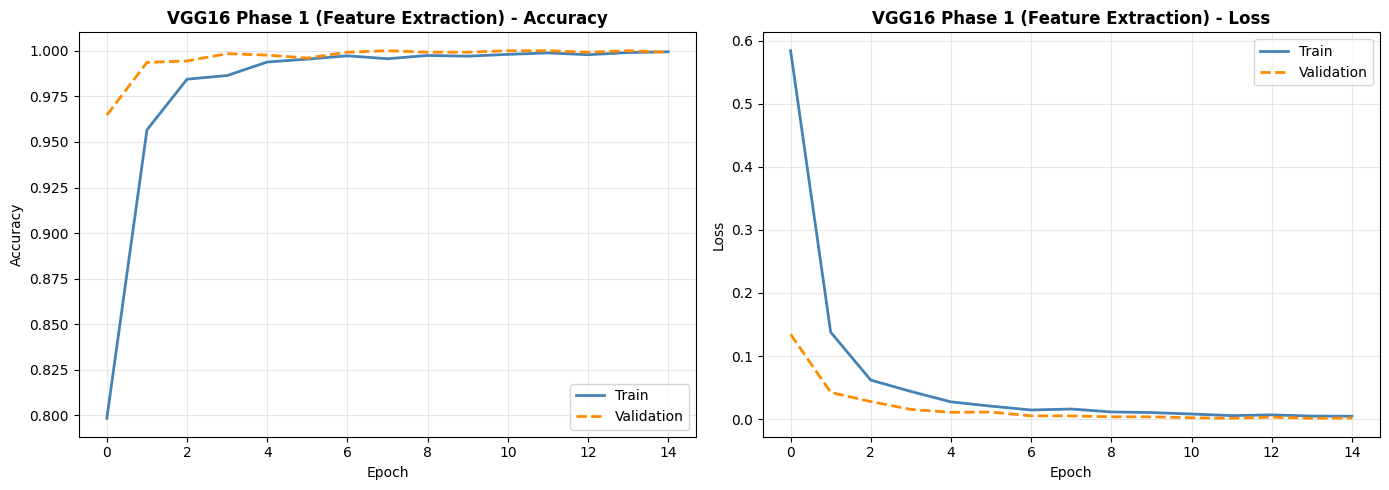

In [32]:
plot_history(history_transfer, title='VGG16 Phase 1 (Feature Extraction)',
             save_name='history_vgg16_p1.png')


## 14. Phase 2 – Fine-Tuning (Unfreeze Last Conv Block)

In [33]:
# Unfreeze last 4 layers of VGG16 (block5)
base_model.trainable = True
FREEZE_UNTIL = len(base_model.layers) - 4
for layer in base_model.layers[:FREEZE_UNTIL]:
    layer.trainable = False

print(f'Frozen : {FREEZE_UNTIL} layers')
print(f'Unfrozen: {len(base_model.layers) - FREEZE_UNTIL} layers (block5)')

# Recompile with very low LR to avoid catastrophic forgetting
transfer_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

tl_cb_p2 = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_vgg16_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Phase 2: Fine-Tuning (block5 unfrozen, LR=1e-5)...')
t0 = time.time()
history_finetune = transfer_model.fit(
    tl_train, validation_data=tl_valid,
    epochs=15, callbacks=tl_cb_p2, verbose=1
)
tl_p2_time = time.time() - t0
print(f'Phase 2 time: {tl_p2_time:.1f}s  Best Val Acc: {max(history_finetune.history["val_accuracy"])*100:.2f}%')


Frozen : 15 layers
Unfrozen: 4 layers (block5)
Phase 2: Fine-Tuning (block5 unfrozen, LR=1e-5)...
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9986 - loss: 0.0054
Epoch 1: val_accuracy improved from None to 1.00000, saving model to best_vgg16_finetuned.keras

Epoch 1: finished saving model to best_vgg16_finetuned.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 108s 630ms/step - accuracy: 0.9988 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 1.3716e-04 - learning_rate: 1.0000e-05
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.9998 - loss: 0.0015
Epoch 2: val_accuracy did not improve from 1.00000
157/157 ━━━━━━━━━━━━━━━━━━━━ 94s 595ms/step - accuracy: 0.9998 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 1.4058e-04 - learning_rate: 1.0000e-05
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9996 - loss: 0.0020
Epoch 3: val_accuracy did not improve from 1.00000
157/157 ━━━━━━━━━━━━━━━━━━━━ 93s 594ms/step - accuracy: 0.9998 - loss: 0.

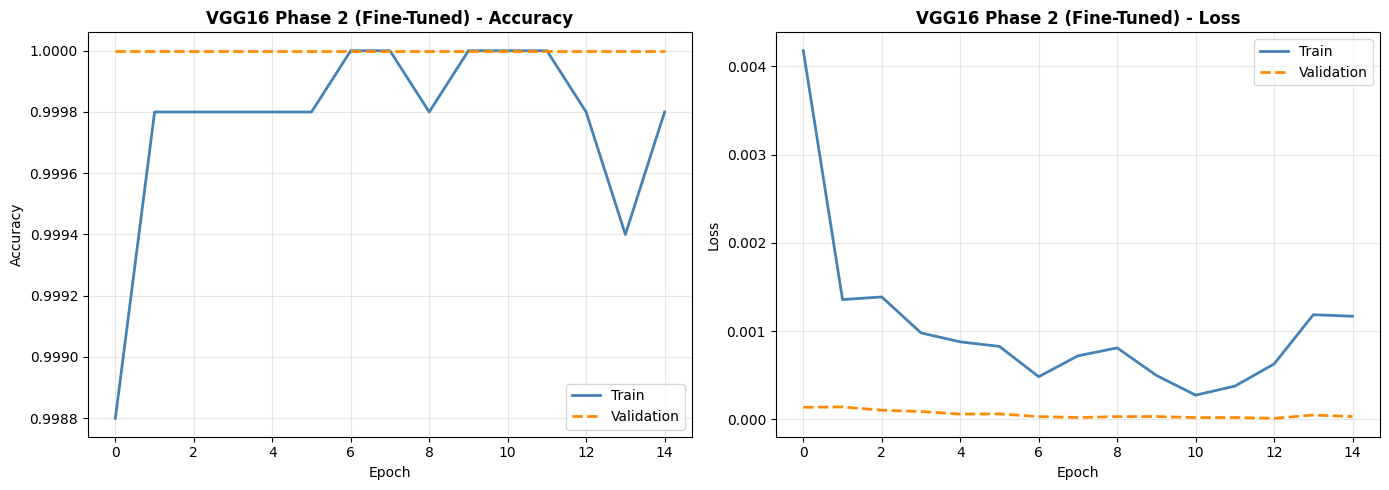

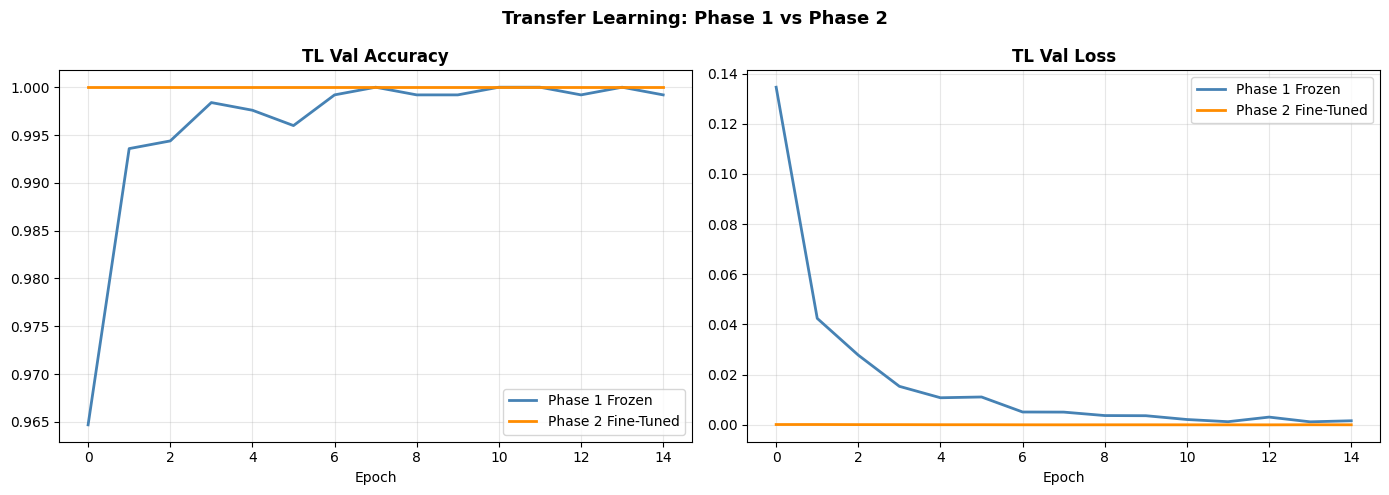

In [34]:
plot_history(history_finetune, title='VGG16 Phase 2 (Fine-Tuned)',
             save_name='history_vgg16_p2.png')

# Phase 1 vs Phase 2 comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, lbl, color in [
    (history_transfer, 'Phase 1 Frozen',    'steelblue'),
    (history_finetune, 'Phase 2 Fine-Tuned','darkorange')
]:
    axes[0].plot(hist.history['val_accuracy'], label=lbl, color=color, lw=2)
    axes[1].plot(hist.history['val_loss'],     label=lbl, color=color, lw=2)
for ax, t in zip(axes, ['Val Accuracy', 'Val Loss']):
    ax.set_title(f'TL {t}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Transfer Learning: Phase 1 vs Phase 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_phase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Transfer Learning Evaluation


  VGG16 Fine-Tuned - Evaluation Report
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       284
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       293
       Mango       1.00      1.00      1.00       181
       Peach       1.00      1.00      1.00       244

    accuracy                           1.00      1246
   macro avg       1.00      1.00      1.00      1246
weighted avg       1.00      1.00      1.00      1246



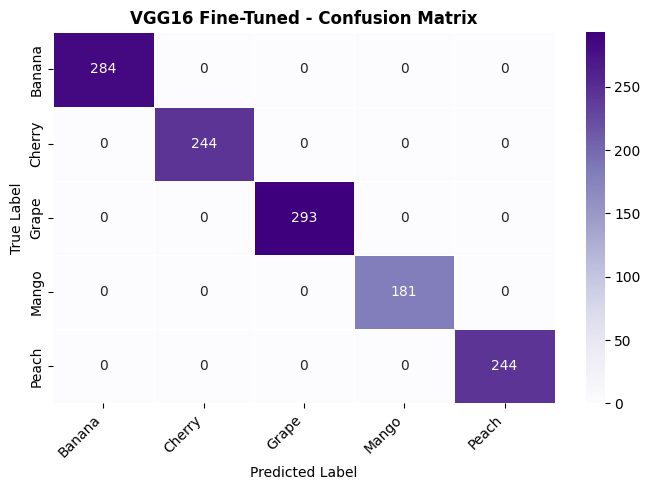

In [35]:
def full_evaluate_tl(model, generator, model_name='Model', cmap='Purples'):
    """Same as full_evaluate but works with tl_valid generator."""
    generator.reset()
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes
    names  = list(generator.class_indices.keys())
    print(f'\n{"="*55}')
    print(f'  {model_name} - Evaluation Report')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(7, len(names)), max(5, len(names)-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=names, yticklabels=names, linewidths=.5)
    plt.title(f'{model_name} - Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

full_evaluate_tl(transfer_model, tl_valid, model_name='VGG16 Fine-Tuned', cmap='Purples')


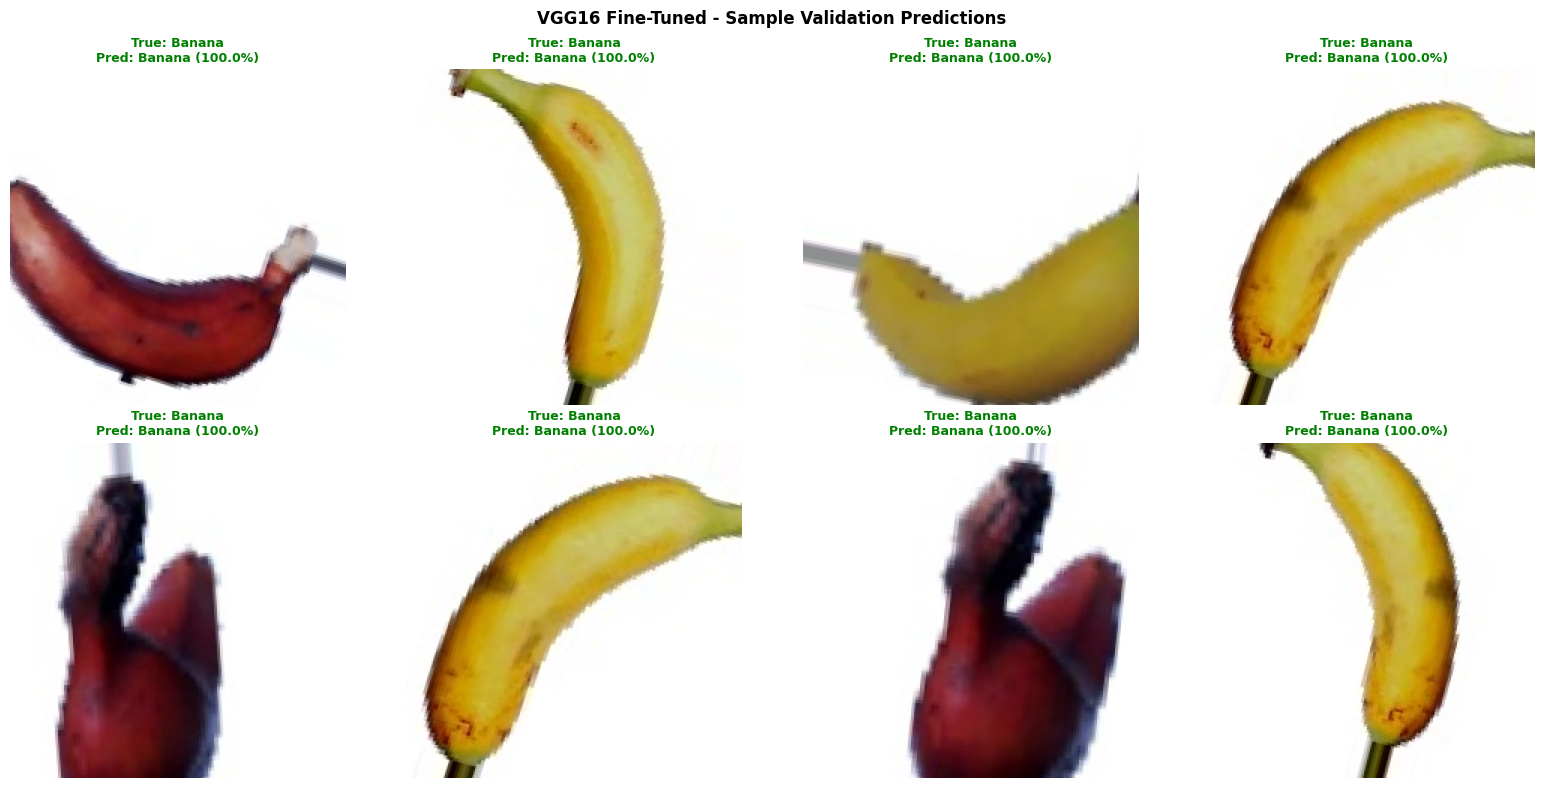

In [36]:
# Sample inference on validation images for VGG16
# Need custom version since tl_valid uses vgg_preprocess (not /255)
tl_valid.reset()
imgs_shown, labels_shown = [], []
for imgs, labels in tl_valid:
    imgs_shown.append(imgs); labels_shown.append(labels)
    if sum(len(l) for l in labels_shown) >= 8: break
imgs_all   = np.concatenate(imgs_shown,   axis=0)[:8]
labels_all = np.concatenate(labels_shown, axis=0)[:8]
preds      = transfer_model.predict(imgs_all, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(8):
    true_cls = classes[np.argmax(labels_all[i])]
    pred_cls = classes[np.argmax(preds[i])]
    conf     = np.max(preds[i]) * 100
    color    = 'green' if pred_cls == true_cls else 'red'
    # Un-preprocess VGG image for display
    disp = imgs_all[i] + [103.939, 116.779, 123.68]   # reverse vgg_preprocess mean subtract
    disp = np.clip(disp[..., ::-1] / 255.0, 0, 1)     # BGR→RGB, clip
    axes[i].imshow(disp); axes[i].axis('off')
    axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                      color=color, fontsize=9, fontweight='bold')
plt.suptitle('VGG16 Fine-Tuned - Sample Validation Predictions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('preds_VGG16_FineTuned.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 16. Final Model Comparison – All Models

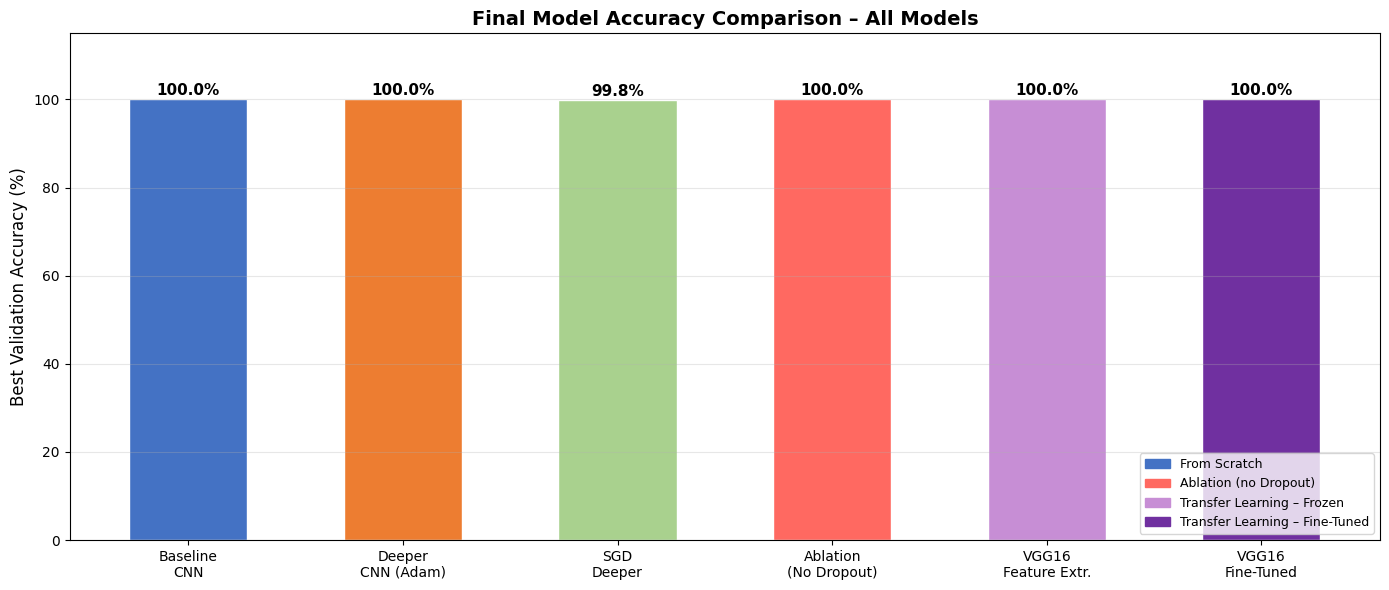


Final Summary:
Model                            Best Val Acc
----------------------------------------------
Baseline CNN                          100.00%
Deeper CNN (Adam)                     100.00%
SGD Deeper                             99.84%
Ablation (No Dropout)                 100.00%
VGG16 Feature Extr.                   100.00%
VGG16 Fine-Tuned                      100.00%
----------------------------------------------
Best overall:                         100.00%


In [37]:
def get_best(hist):
    return max(hist.history['val_accuracy']) * 100

model_names = [
    'Baseline\nCNN',
    'Deeper\nCNN (Adam)',
    'SGD\nDeeper',
    'Ablation\n(No Dropout)',
    'VGG16\nFeature Extr.',
    'VGG16\nFine-Tuned'
]
accuracies = [
    get_best(history),
    get_best(history_deeper),
    get_best(history_sgd),
    get_best(history_ablation),
    get_best(history_transfer),
    get_best(history_finetune),
]

colours = ['#4472C4','#ED7D31','#A9D18E','#FF6961','#C78ED5','#7030A0']
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(model_names, accuracies, color=colours, width=0.55, edgecolor='white')
ax.set_ylim(0, 115)
ax.set_ylabel('Best Validation Accuracy (%)', fontsize=12)
ax.set_title('Final Model Accuracy Comparison – All Models',
             fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
legend_patches = [
    mpatches.Patch(color='#4472C4', label='From Scratch'),
    mpatches.Patch(color='#FF6961', label='Ablation (no Dropout)'),
    mpatches.Patch(color='#C78ED5', label='Transfer Learning – Frozen'),
    mpatches.Patch(color='#7030A0', label='Transfer Learning – Fine-Tuned'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFinal Summary:')
print(f'{"Model":<32} {"Best Val Acc":>12}')
print('-'*46)
for n, a in zip(model_names, accuracies):
    print(f'{n.replace(chr(10)," "):<32} {a:>11.2f}%')
print('-'*46)
print(f'{"Best overall:":<32} {max(accuracies):>11.2f}%')


In [38]:
# Save all models
model.save('final_baseline_cnn.keras')
deeper_model.save('final_deeper_cnn.keras')
transfer_model.save('final_vgg16_finetuned.keras')
print('All models saved.')


All models saved.
